In [1]:
print("Task 1: Environment check")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")

Task 1: Environment check
All libraries imported successfully!


In [2]:
print("Task 2 & 3:  Load dataset & First look")
data = pd.read_csv('penguins.csv')
print("Dataset loaded successfully!")
print(f"First ten rows:\n{data.head(10)}")
print(f"Amounf of Rows and Colums:\n{data.shape}")
print(f"Columns Names:\n{data.columns}")
print(f"All types:\n{data.dtypes}")

Task 2 & 3:  Load dataset & First look
Dataset loaded successfully!
First ten rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0     NaN  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3     NaN  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6     NaN  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   
8     NaN  Torgersen            34.1           18.1              193.0   
9  Adelie        NaN            42.0            NaN              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3

In [3]:
print("Task 4: Missing values")
missing_counts = data.isnull().sum()
missing_percentages = (missing_counts / len(data)) * 100
print(f"Count missing values per column:\n{missing_counts}")
print(f"\nCalculate percentage of missing values:\n{missing_percentages}")
data = data.dropna()
print(f"\nShape of dataset after dropping missing values: {data.shape}")

Task 4: Missing values
Count missing values per column:
species              18
island               18
bill_length_mm       28
bill_depth_mm        25
flipper_length_mm    19
body_mass_g          21
sex                  33
dtype: int64

Calculate percentage of missing values:
species              5.232558
island               5.232558
bill_length_mm       8.139535
bill_depth_mm        7.267442
flipper_length_mm    5.523256
body_mass_g          6.104651
sex                  9.593023
dtype: float64

Shape of dataset after dropping missing values: (214, 7)


In [4]:
print("Task 5: Summary statistics")
print(f"Describe Table:\n{data.describe()}")
print("\n--- Numeric Column Metrics: body_mass_g ---")
print(f"\nAverage body mass (g): {data['body_mass_g'].mean():.2f}")
print(f"Median body mass (g): {data['body_mass_g'].median():.2f}")
print(f"Standard deviation of body mass (g): {data['body_mass_g'].std():.2f}")
q1 = data['body_mass_g'].quantile(0.25)
q3 = data['body_mass_g'].quantile(0.75)
iqr = q3 - q1
print(f"Interquartile Range (IQR) body mass (g): {iqr:.2f}")
print("\n--- Categorical Column Metrics: species ---")
print(f"\nValue counts for penguin species:{data['species'].value_counts()}")

Task 5: Summary statistics
Describe Table:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      214.000000     214.000000         214.000000   214.000000
mean        43.746262      17.225701         200.560748  4184.462617
std          5.321800       1.982587          13.732643   806.888515
min         32.100000      13.100000         172.000000  2700.000000
25%         39.200000      15.800000         190.000000  3550.000000
50%         44.050000      17.500000         196.500000  4000.000000
75%         48.575000      18.700000         212.000000  4768.750000
max         55.800000      21.500000         230.000000  6000.000000

--- Numeric Column Metrics: body_mass_g ---

Average body mass (g): 4184.46
Median body mass (g): 4000.00
Standard deviation of body mass (g): 806.89
Interquartile Range (IQR) body mass (g): 1218.75

--- Categorical Column Metrics: species ---

Value counts for penguin species:species
Adelie       100
Gentoo        73
Chinstrap     4

Task 6: Three visualizations


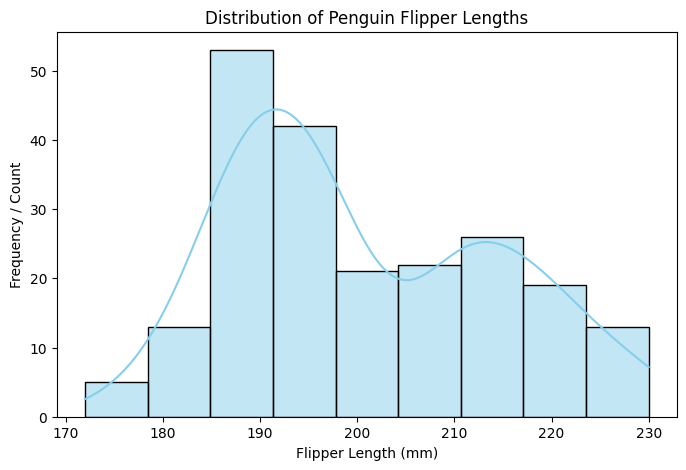

Interpretation 1 (Histogram): The histogram shows a slightly bimodal (two-peaked) distribution, suggesting that the dataset contains distinct groups, likely corresponding to the different penguin species.


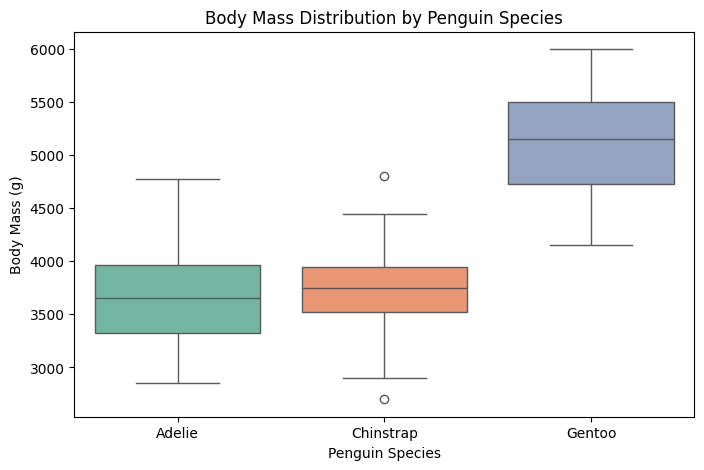

Interpretation 2 (Boxplot): The boxplot clearly shows that Gentoo penguins are significantly heavier on average than both Adelie and Chinstrap penguins, which share a similar weight range.


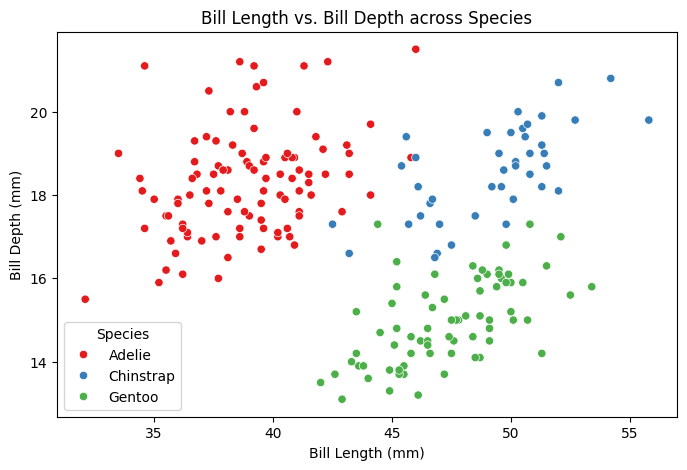

Interpretation 3 (Scatter Plot): The scatter plot reveals distinct physical clusters for each species, such as Adelie penguins having short, deep bills compared to Gentoo penguins having long, shallow bills.


In [5]:
print("Task 6: Three visualizations")
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='flipper_length_mm', kde=True, color='skyblue')
plt.title('Distribution of Penguin Flipper Lengths')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Frequency / Count')
plt.show()

print("Interpretation 1 (Histogram): The histogram shows a slightly bimodal (two-peaked) distribution, suggesting that the dataset contains distinct groups, likely corresponding to the different penguin species.")

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='species', y='body_mass_g', hue='species', palette='Set2', legend=False)
plt.title('Body Mass Distribution by Penguin Species')
plt.xlabel('Penguin Species')
plt.ylabel('Body Mass (g)')
plt.show()

print("Interpretation 2 (Boxplot): The boxplot clearly shows that Gentoo penguins are significantly heavier on average than both Adelie and Chinstrap penguins, which share a similar weight range.")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='bill_length_mm', y='bill_depth_mm', hue='species', palette='Set1')
plt.title('Bill Length vs. Bill Depth across Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.legend(title='Species')
plt.show()

print("Interpretation 3 (Scatter Plot): The scatter plot reveals distinct physical clusters for each species, such as Adelie penguins having short, deep bills compared to Gentoo penguins having long, shallow bills.")

In [6]:
print("Task 7: Two questions")
print("Question 1: Which penguin species has the longest average flipper length?")
flipper_by_species = data.groupby('species')['flipper_length_mm'].mean().sort_values(ascending=False)
print(f"Data Output:\n{flipper_by_species}")
print("Answer: Gentoo penguins have the longest flippers by a wide margin, averaging over 217 mm.\n")
print("-" * 80)

print("Question 2: How does the average body mass differ between male and female penguins?")
mass_by_sex = data.groupby('sex')['body_mass_g'].mean()
print(f"Data Output:\n{mass_by_sex}")
print("Answer: Across all species, male penguins are noticeably heavier on average than female penguins.")
print("-" * 80)

Task 7: Two questions
Question 1: Which penguin species has the longest average flipper length?
Data Output:
species
Gentoo       217.068493
Chinstrap    195.780488
Adelie       190.470000
Name: flipper_length_mm, dtype: float64
Answer: Gentoo penguins have the longest flippers by a wide margin, averaging over 217 mm.

--------------------------------------------------------------------------------
Question 2: How does the average body mass differ between male and female penguins?
Data Output:
sex
Female    3830.952381
Male      4525.000000
Name: body_mass_g, dtype: float64
Answer: Across all species, male penguins are noticeably heavier on average than female penguins.
--------------------------------------------------------------------------------


In [7]:
print("Task 8: Reflection ")
print("The trickiest part of this assignment was writing the code for the grouped charts, but I was genuinely surprised by how clearly the physical measurements separated the penguin species into distinct clusters. A logical next step would be using this clean dataset to build a machine learning model that can automatically predict a penguin's species. For this project, I used an AI assistant to brainstorm ideas for the visualizations, and I am really happy that I got to practice and write the actual code myself.")

Task 8: Reflection 
The trickiest part of this assignment was writing the code for the grouped charts, but I was genuinely surprised by how clearly the physical measurements separated the penguin species into distinct clusters. A logical next step would be using this clean dataset to build a machine learning model that can automatically predict a penguin's species. For this project, I used an AI assistant to brainstorm ideas for the visualizations, and I am really happy that I got to practice and write the actual code myself.
